# Stage 3 — Data Cleaning
**Input:** `data/01_raw/dataset.csv`  
**Output:** `data/03_interim/accidents_cleaned.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RAW_DIR     = Path('../../data/01_raw')
INTERIM_DIR = Path('../../data/03_interim')
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RAW_DIR / 'dataset.csv')
print('Raw shape:', df.shape)

Raw shape: (1240, 15)


## 3.1 Missing Values

Accident_Date         10
District              90
Time_of_Day           73
Weather_Condition    151
Road_Surface         136
Driver_Gender        114
dtype: int64


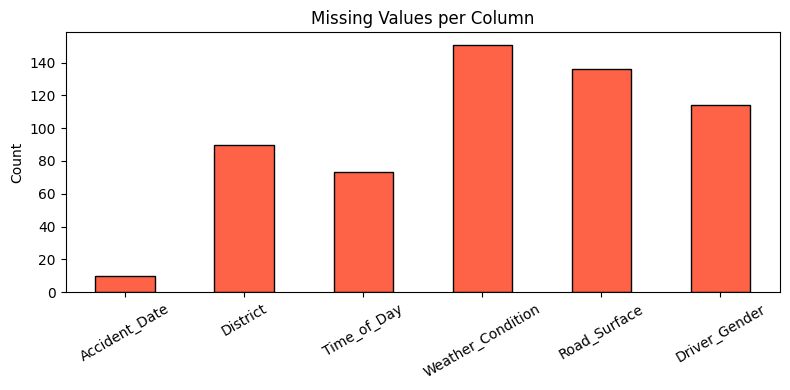

In [2]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

fig, ax = plt.subplots(figsize=(8, 4))
missing.plot(kind='bar', color='tomato', edgecolor='black', ax=ax)
ax.set_title('Missing Values per Column')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [3]:
# Fill missing categorical columns with mode
cat_fill = ['Weather_Condition', 'Road_Surface', 'Driver_Gender', 'District', 'Time_of_Day']
for col in cat_fill:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f'{col} → filled with "{mode_val}"')

print('\nMissing after fill:', df.isnull().sum().sum())

Weather_Condition → filled with "Clear"
Road_Surface → filled with "Wet"
Driver_Gender → filled with "Male"
District → filled with "Sunsari"
Time_of_Day → filled with "Afternoon"

Missing after fill: 10


## 3.2 Duplicate Rows

In [4]:
print('Duplicates before:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print('Duplicates after:', df.duplicated().sum())
print('Shape after removing duplicates:', df.shape)

Duplicates before: 33
Duplicates after: 0
Shape after removing duplicates: (1207, 15)


## 3.3 Fix Label Inconsistencies in Accident_Severity

In [5]:
print('Before fix:', df['Accident_Severity'].unique())

# Standardise: strip whitespace + title case
df['Accident_Severity'] = df['Accident_Severity'].str.strip().str.title()

# Fix remaining typo
df['Accident_Severity'] = df['Accident_Severity'].replace({'Fatall': 'Fatal'})

print('After fix:', sorted(df['Accident_Severity'].unique()))

Before fix: <StringArray>
[   'Damage Only', 'Serious Injury',   'Minor Injury',          'Fatal',
    'damage only',   'minor injury', 'Serious injury',         'Fatall']
Length: 8, dtype: str
After fix: ['Damage Only', 'Fatal', 'Minor Injury', 'Serious Injury']


## 3.4 Fix Province Casing

In [6]:
print('Before fix:', sorted(df['Province'].unique()))
df['Province'] = df['Province'].str.strip().str.title()
print('After fix:', sorted(df['Province'].unique()))

Before fix: ['BAGMATI', 'Bagmati', 'GANDAKI', 'Gandaki', 'KOSHI', 'Karnali', 'Koshi', 'LUMBINI', 'Lumbini', 'MADHESH', 'Madhesh', 'SUDURPASHCHIM', 'Sudurpashchim']
After fix: ['Bagmati', 'Gandaki', 'Karnali', 'Koshi', 'Lumbini', 'Madhesh', 'Sudurpashchim']


## 3.5 Fix Outlier Speed_Zone

In [7]:
print('Speed_Zone values before:', sorted(df['Speed_Zone'].unique()))
# Replace outlier 999 with median of valid values
valid_median = df[df['Speed_Zone'] != 999]['Speed_Zone'].median()
df.loc[df['Speed_Zone'] == 999, 'Speed_Zone'] = valid_median
print('Speed_Zone values after:', sorted(df['Speed_Zone'].unique()))

Speed_Zone values before: [np.int64(30), np.int64(50), np.int64(80), np.int64(999)]
Speed_Zone values after: [np.int64(30), np.int64(50), np.int64(80)]


## 3.6 Fix Year Mismatch

In [8]:
print('Bad Year rows before:', (df['Year'] == 1999).sum())
valid_dates = pd.to_datetime(df['Accident_Date'], errors='coerce')
df.loc[df['Year'] == 1999, 'Year'] = valid_dates[df['Year'] == 1999].dt.year
df['Year'] = df['Year'].fillna(df['Year'].mode()[0])
df['Year'] = df['Year'].astype(int)
print('Bad Year rows after:', (df['Year'] == 1999).sum())

Bad Year rows before: 16
Bad Year rows after: 0


## 3.7 Fix Corrupted Dates

In [9]:
print('N/A dates before:', (df['Accident_Date'] == 'N/A').sum())
df['Accident_Date'] = pd.to_datetime(df['Accident_Date'], errors='coerce')
df['Accident_Date'] = df['Accident_Date'].ffill()
print('NaT dates after:', df['Accident_Date'].isnull().sum())

N/A dates before: 0
NaT dates after: 0


## 3.8 Final Quality Check

In [10]:
print('Final shape:', df.shape)
print('Missing values:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
print('Severity classes:', sorted(df['Accident_Severity'].unique()))
df.head()

Final shape: (1207, 15)
Missing values: 0
Duplicates: 1
Severity classes: ['Damage Only', 'Fatal', 'Minor Injury', 'Serious Injury']


,Accident_ID,Accident_Date,Year,Month,Province,District,Road_Type,Intersection_Type,Time_of_Day,Accident_Severity,Weather_Condition,Road_Surface,Vehicle_Type,Speed_Zone,Driver_Gender
0,1179,2026-01-09,2026,January,Sudurpashchim,Kailali,Highway,Junction,Afternoon,Damage Only,Clear,Slippery,Scooter,50,Male
1,866,2025-03-07,2025,March,Bagmati,Chitwan,Feeder,Curve,Evening,Serious Injury,Clear,Dry,Car,50,Female
2,102,2023-03-23,2023,March,Lumbini,Kapilvastu,Urban,Straight,Morning,Damage Only,Clear,Dry,Truck,30,Male
3,440,2024-02-16,2024,February,Madhesh,Rautahat,Urban,Curve,Afternoon,Minor Injury,Clear,Slippery,Motorbike,80,Male
4,59,2023-02-10,2023,February,Sudurpashchim,Achham,Urban,Straight,Night,Serious Injury,Clear,Wet,Scooter,50,Male


## 3.9 Save Cleaned Dataset

In [11]:
df.to_csv(INTERIM_DIR / 'accidents_cleaned.csv', index=False)
print('Saved to:', INTERIM_DIR / 'accidents_cleaned.csv')
print('Shape:', df.shape)

Saved to: ../../data/03_interim/accidents_cleaned.csv
Shape: (1207, 15)
